In [2]:
from utils.data import DataManager
from utils.preprocess import DataPreprocessor
import pandas as pd

data_manager = DataManager()
data_manager.preparar_conjuntos()

X_train, y_train, weights_train = data_manager.get_train_data()
X_test, y_test, weights_test = data_manager.get_test_data()

test = data_manager.get_test()
weights = data_manager.get_weights()

X, y = data_manager.get_X_y()

data_preprocessor = DataPreprocessor()

X_test = data_preprocessor.fit_transform(X_test)
X_train = data_preprocessor.transform(X_train)

transf_test = data_preprocessor.transform(test)
X = data_preprocessor.transform(X)

In [3]:
import tensorflow as tf
import keras_tuner as kt

norm_layer = tf.keras.layers.Normalization()
norm_layer.adapt(X_train)

In [7]:
from utils.HiggsBosonCompetition_AMSMetric_rev1 import AMS
import numpy as np

def ams_loss(y_true, y_pred):
    """ Custom scorer function for calculating AMS.

    Args:
        y_true (array): True labels.
        y_pred (array): Predicted labels.
        weights (array): Event weights.

    Returns:
        float: The calculated AMS score.
    """

    signal = np.sum(weights[y_true & y_pred])
    background = np.sum(weights[~y_true & y_pred])

    return AMS(signal, background)

In [23]:
def build_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=5, max_value=5)
    #n_neurons = [hp.Int(f"n_neurons{i}", min_value=16, max_value=70) for i in range(n_hidden)]
    n_neurons = [60, 33, 53, 64, 42]

    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
   
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
    model.add(norm_layer)
    for i in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons[i], activation="relu", kernel_initializer="he_normal"))
        
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(loss="binary_crossentropy", optimizer=tf.keras.optimizers.Nadam(learning_rate=learning_rate),
              weighted_metrics=[])

    return model

In [ ]:
hyperband = kt.Hyperband(
    build_model,
    objective="val_loss",
    max_epochs=200,
    overwrite=False,
    directory="nn_model",
    project_name="nn_model_hyperband",
    seed=42
)

early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
hyperband.search(X_train, y_train, epochs=200, 
                 validation_data=(X_test, y_test, weights_test), callbacks=[early], 
                 sample_weight=weights_train)

best_model = hyperband.get_best_models(num_models=1)[0]
best_model.summary()
best_model.save("second_best_model.h5")

In [28]:
hyperband = kt.Hyperband(
    build_model,
    objective="val_loss",
    max_epochs=200,
    overwrite=False,
    directory="nn_model",
    project_name="nn_model_hyperband",
    seed=42
)

best_model = hyperband.get_best_models(num_models=1)[0]
best_model.summary()
best_model.save("second_best_model.h5")

Reloading Tuner from nn_model\nn_model_hyperband\tuner0.json


c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\keras_tuner\src\tuners\hyperband.py:435: UserWarning: Model 'sequential' had a build config, but the model cannot be built automatically in `build_from_config(config)`. You should implement `def build_from_config(self, config)`, and you might also want to implement the method  that generates the config at saving time, `def get_build_config(self)`. The method `build_from_config()` is meant to create the state of the model (i.e. its variables) upon deserialization.
  model.build_from_config(
c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\keras\src\saving\saving_lib.py:415: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 27 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 36)             │            73 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60)             │         2,220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         2,013 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 53)             │         1,802 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 42)             │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,337 (48.20 KB)

 Trainable params: 12,264 (47.91 KB)

 Non-trainable params: 73 (296.00 B)

In [36]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = best_model.fit(
    X_train, y_train, 
    sample_weight=weights_train, 
    epochs=100,
    verbose=1, 
    callbacks=[early_stopping],
    validation_data=(X_test, y_test, weights_test)
)

Epoch 1/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 668us/step - loss: 0.0151 - val_loss: 0.0149
Epoch 2/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 651us/step - loss: 0.0162 - val_loss: 0.0149
Epoch 3/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 654us/step - loss: 0.0149 - val_loss: 0.0151
Epoch 4/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 649us/step - loss: 0.0150 - val_loss: 0.0150
Epoch 5/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 655us/step - loss: 0.0150 - val_loss: 0.0150
Epoch 6/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 650us/step - loss: 0.0149 - val_loss: 0.0151
Epoch 7/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 658us/step - loss: 0.0149 - val_loss: 0.0150
Epoch 8/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 649us/step - loss: 0.0160 - val_loss: 0.0151
Epoch 9/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 652us/step - loss: 0.0151 - val_loss: 0.0150
Epoch 10/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 667us/step - loss: 0.0151 - val_loss: 0.0151
Epoch 11/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 667us/step - loss: 0.0149 - val_loss: 0.01

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 407us/step
[0.00000000e+00 2.48602696e-04 2.70442815e-04 ... 3.62490051e-05
 1.37563739e-05 0.00000000e+00]


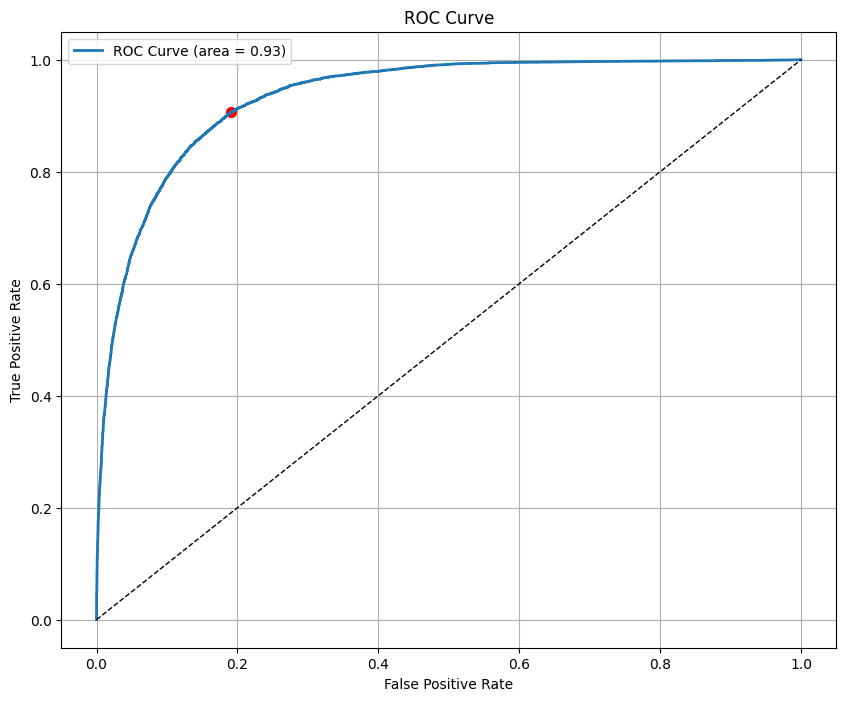

Best Threshold: 0.0010273575


In [37]:
from sklearn.metrics import auc
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import numpy as np
from sklearn.metrics import roc_auc_score

y_scores = np.array(best_model.predict(X_test)).flatten()
fpr, tpr, thresholds_auc = roc_curve(y_test, y_scores, sample_weight=weights_test)

J = tpr - fpr
print(J)
idx = np.argmax(J)

auc = roc_auc_score(y_test, y_scores, sample_weight=weights_test)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc:.2f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.scatter(fpr[idx], tpr[idx], c='red', s=50)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

best_thresh = thresholds_auc[idx]
print("Best Threshold:", best_thresh)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 407us/step


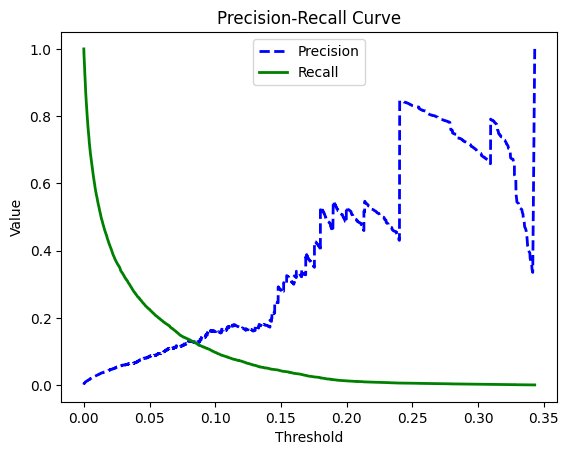

In [38]:
from utils.metrics import MetricsManager
import utils.metrics as m
from importlib import reload
reload(m)
import numpy as np

y_pred_proba = np.array(best_model.predict(X_test)).flatten()
y_true = y_test

MetricsManager.plot_precision_recall_vs_threshold(y_true, y_pred_proba, sample_weight=weights_test)


In [39]:
from sklearn.metrics import precision_recall_curve
import importlib
import utils.HiggsBosonCompetition_AMSMetric_rev1 as hb_metrics

importlib.reload(hb_metrics)

y_test_scores = best_model.predict(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_test_scores, sample_weight=weights_test)

best_ams = 0
best_threshold = 1

ams_scores = []
threshold_values = []

for i in range(len(thresholds)):
    y_pred = (y_test_scores >= thresholds[i]).astype(int)
    y_pred = y_pred.flatten()
    ams = hb_metrics.ams_scorer(y_test, y_pred, weights_test)

    ams_scores.append(ams)
    threshold_values.append(thresholds[i])

    if ams > best_ams:
        best_ams = ams
        best_threshold = thresholds[i]



1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 420us/step


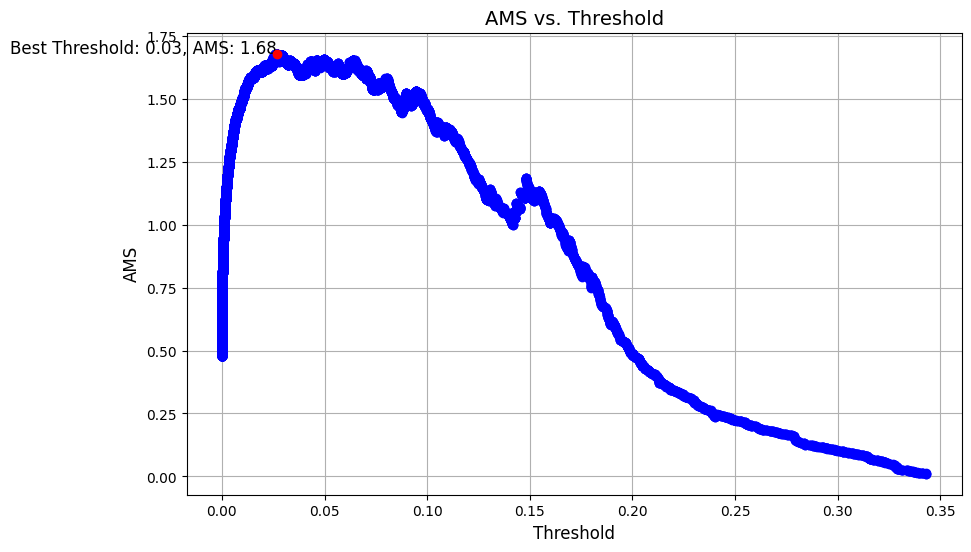

In [40]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.plot(threshold_values, ams_scores, marker='o', linestyle='-', color='b')

best_idx = np.argmax(ams_scores)
best_threshold = threshold_values[best_idx]
best_ams = ams_scores[best_idx]
plt.scatter([best_threshold], [best_ams], color='red', zorder=5)
plt.text(best_threshold, best_ams, f'Best Threshold: {best_threshold:.2f}, AMS: {best_ams:.2f}',
         fontsize=12, ha='right')

plt.title('AMS vs. Threshold', fontsize=14)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('AMS', fontsize=12)
plt.grid(True)
plt.show()


In [51]:
print(f"Best Threshold: {best_threshold}, Best AMS: {best_ams}")

Best Threshold: 0.02672775648534298, Best AMS: 1.6783791754653388


In [57]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = best_model.fit(
    X, y, 
    sample_weight=weights, 
    epochs=100,
    verbose=1, 
    callbacks=[early_stopping],
    validation_split=0.1
)

Epoch 1/100
7032/7032 ━━━━━━━━━━━━━━━━━━━━ 6s 712us/step - loss: 0.0151 - val_loss: 0.0150
Epoch 2/100
7032/7032 ━━━━━━━━━━━━━━━━━━━━ 5s 712us/step - loss: 0.0167 - val_loss: 0.0150
Epoch 3/100
7032/7032 ━━━━━━━━━━━━━━━━━━━━ 5s 689us/step - loss: 0.0152 - val_loss: 0.0150
Epoch 4/100
1942/7032 ━━━━━━━━━━━━━━━━━━━━ 3s 650us/step - loss: 0.0148

In [53]:
y_test_scores = best_model.predict(transf_test)
y_test_pred = (y_test_scores >= best_thresh).astype(int)
y_test_scores = y_test_scores.flatten()
y_test_pred = y_test_pred.flatten()

submission_df = pd.DataFrame({
    "EventId": test["EventId"],
    "Class": y_test_pred,
    "Probability": y_test_scores
})

submission_df = submission_df.sort_values(by='Probability', ascending=False)
submission_df['RankOrder'] = range(1, len(submission_df) + 1)
submission_df['Class'] = submission_df['Class'].map({1: 's', 0: 'b'})
submission_df = submission_df[['EventId', 'Class', 'RankOrder']]
submission_df.to_csv("submission.csv", index=False)

17188/17188 ━━━━━━━━━━━━━━━━━━━━ 7s 412us/step


In [54]:
!kaggle competitions submit -c higgs-boson -f submission.csv -m "Red neuronal grande AUC threshold AAA"

Successfully submitted to Higgs Boson Machine Learning Challenge



  0%|          | 0.00/8.81M [00:00<?, ?B/s]
  1%|          | 96.0k/8.81M [00:00<00:09, 923kB/s]
 10%|▉         | 880k/8.81M [00:00<00:01, 4.98MB/s]
 15%|█▌        | 1.35M/8.81M [00:00<00:01, 4.34MB/s]
 25%|██▌       | 2.22M/8.81M [00:00<00:01, 6.02MB/s]
 32%|███▏      | 2.82M/8.81M [00:00<00:01, 3.15MB/s]
 37%|███▋      | 3.27M/8.81M [00:01<00:02, 2.79MB/s]
 41%|████      | 3.63M/8.81M [00:01<00:01, 2.98MB/s]
 45%|████▌     | 4.00M/8.81M [00:01<00:01, 3.15MB/s]
 50%|████▉     | 4.38M/8.81M [00:01<00:01, 3.32MB/s]
 54%|█████▍    | 4.74M/8.81M [00:01<00:01, 3.45MB/s]
 58%|█████▊    | 5.11M/8.81M [00:01<00:01, 3.52MB/s]
 62%|██████▏   | 5.48M/8.81M [00:01<00:00, 3.60MB/s]
 66%|██████▋   | 5.85M/8.81M [00:01<00:00, 3.68MB/s]
 71%|███████   | 6.22M/8.81M [00:01<00:00, 3.63MB/s]
 75%|███████▍  | 6.58M/8.81M [00:01<00:00, 3.56MB/s]
 79%|███████▊  | 6.93M/8.81M [00:02<00:00, 3.59MB/s]
 83%|████████▎ | 7.28M/8.81M [00:02<00:00, 3.57MB/s]
 87%|████████▋ | 7.63M/8.81M [00:02<00:00, 3.60MB/s]
 91